In [278]:
import numpy as np
import matplotlib.pyplot as plt
import millefeuille as mf

state = mf.State.load(
    "databases/Gorgon_MF_DB_Gorgon_MF_20MA_iceburner2.db"
)

surrogate = mf.MultiOutputRandomForestSurrogate(
    n_outputs=len(state.Y_names),
    verbose=True,
)

surrogate.fit(state)

In [279]:
X_default = np.array([
    0.84e3,     # laser_energy
    2.79e-3,    # R_outer
    1.20e-7,    # Pi_parameter
    3.25e-4,    # Be_thickness
    2.25,       # rho_gas
])

X_pred = np.tile(X_default, (100, 1))


laser_scan = np.linspace(0.4e3, 2e3, 100) #0
R_scan = np.linspace(2.6e-3, 3.2e-3, 100)
PI_scan = np.linspace(1.18e-7,1.27e-7, 100)
Be_scan = np.linspace(2.5e-5, 3.25e-4, 100)
gas_scan = np.linspace(0.5, 10, 100)

X_pred[:, 4] = gas_scan

Y_pred = surrogate.predict(state, X_pred)

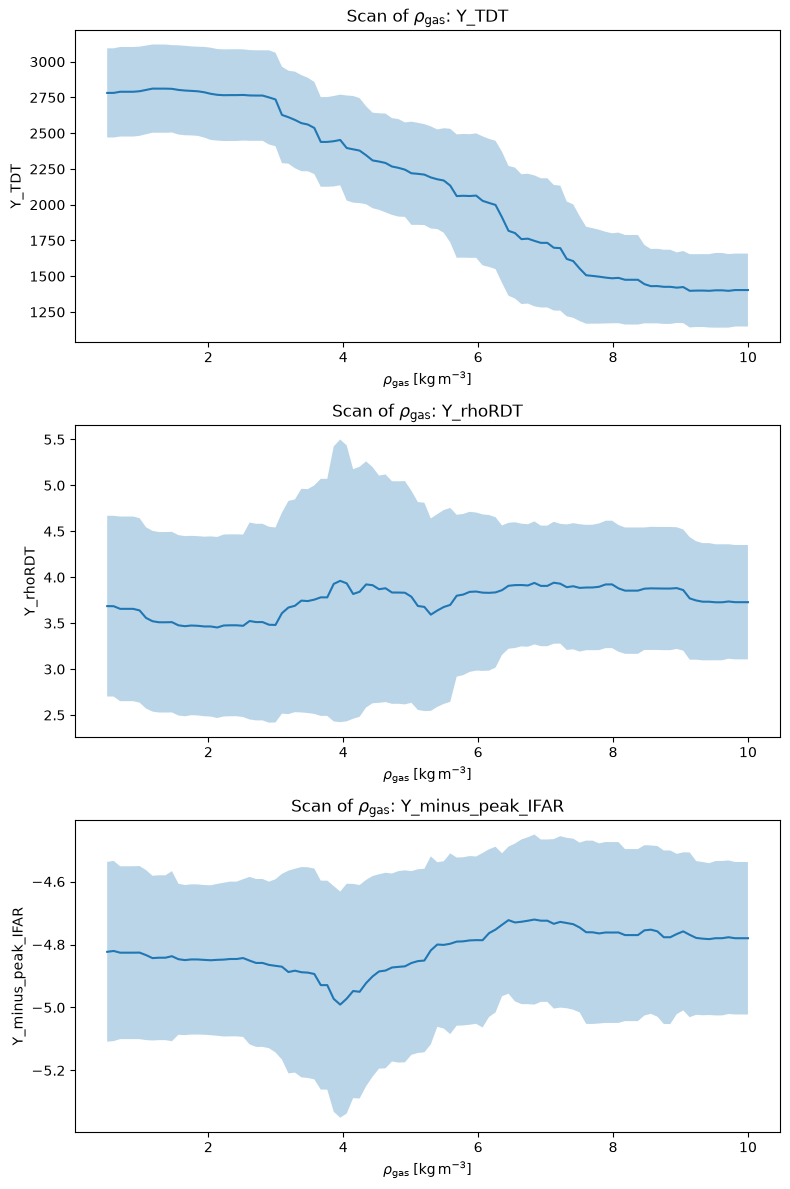

In [280]:
Y_mean = np.asarray(Y_pred["mean"])
Y_std = np.asarray(Y_pred["std"])

fig, axes = plt.subplots(
    len(state.Y_names),
    1,
    figsize=(8, 4 * len(state.Y_names))
)

for i, name in enumerate(state.Y_names):
    mean = Y_mean[:, i]
    std = Y_std[:, i]

    axes[i].plot(gas_scan, mean)
    axes[i].fill_between(
        gas_scan,
        mean - std,
        mean + std,
        alpha=0.3
    )

    axes[i].set_xlabel(r"$\rho_{\mathrm{gas}}\;[\mathrm{kg\,m^{-3}}]$")
    axes[i].set_ylabel(name)
    axes[i].set_title(rf"Scan of $\rho_{{\mathrm{{gas}}}}$: {name}")

plt.tight_layout()
plt.show()

X prediction shape: (5000, 5)
Unique R_outer values: [0.00279]
Objective prediction shape: (5000, 3)
(# surrogate samples, # variables)
Samples shape: (5000, 7)


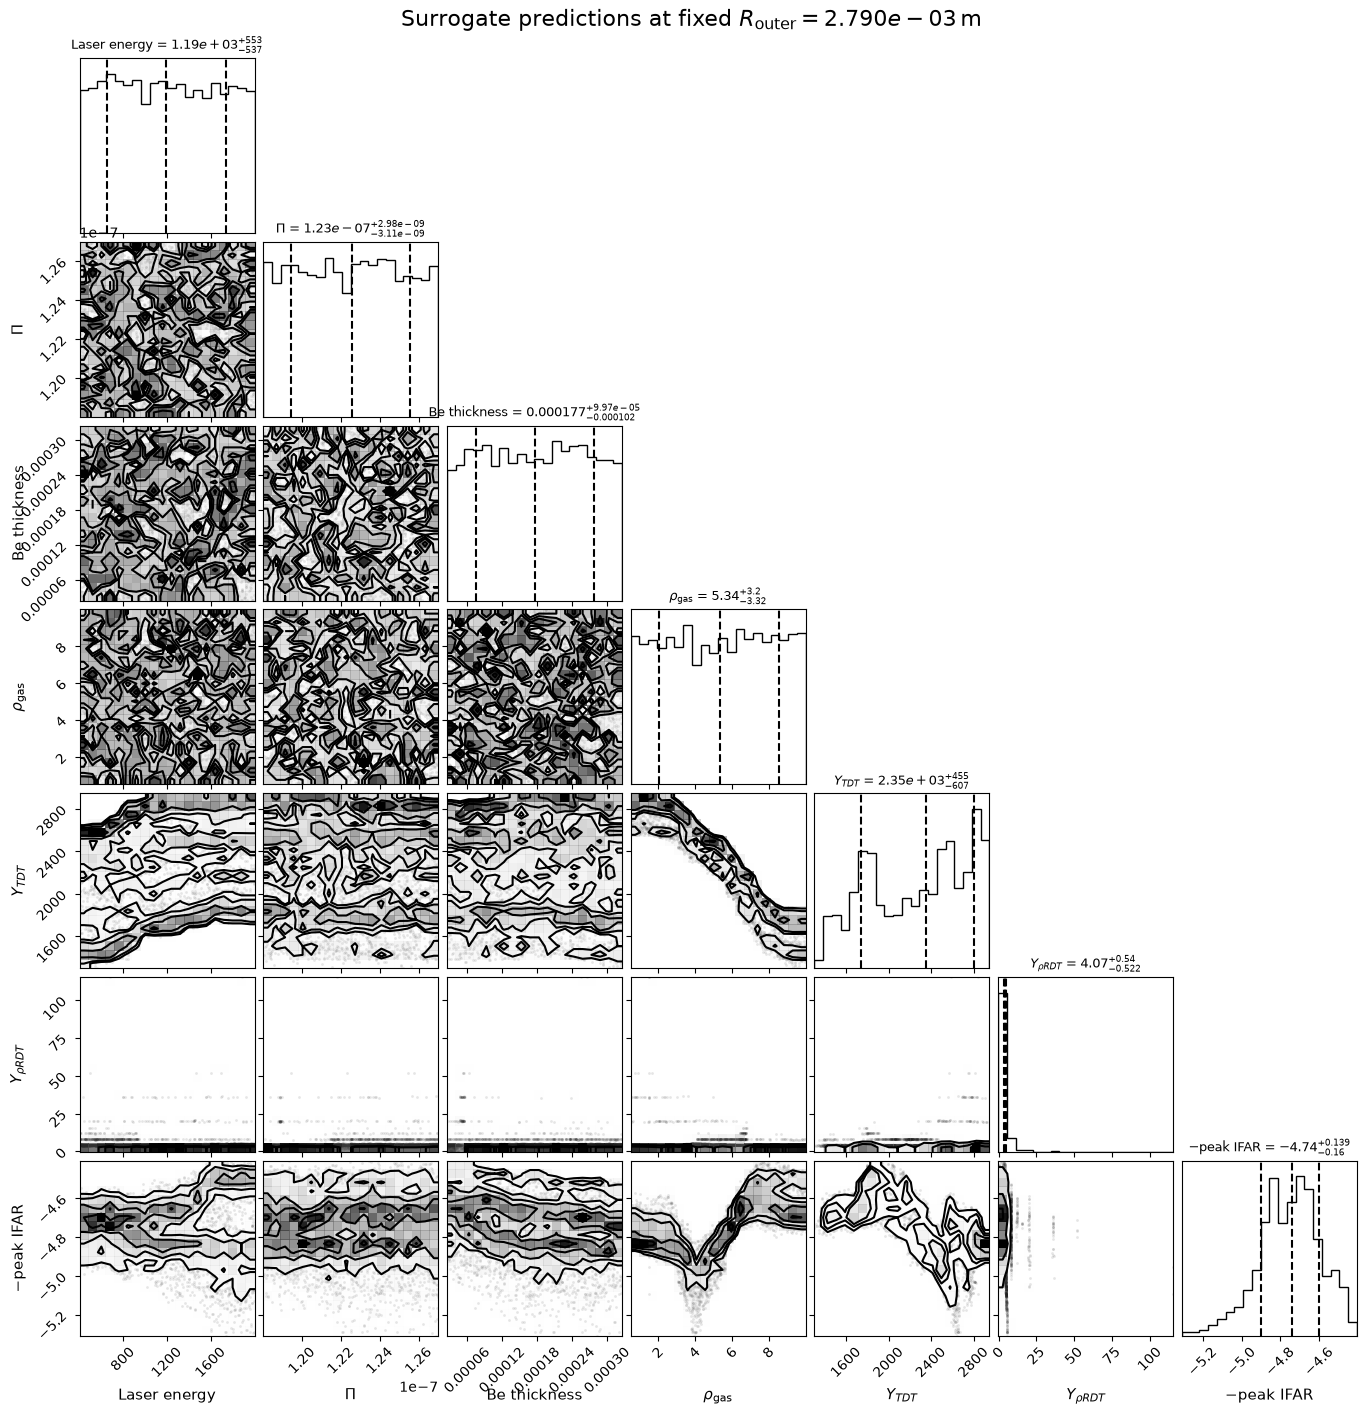

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner

# ---------------------------------------------------------
# 1. Generate samples with R_outer fixed
# ---------------------------------------------------------

rng = np.random.default_rng(42)

n_samples = 5000
R_outer_fixed = 2.79e-3

X_pred = np.column_stack([
    rng.uniform(0.4e3, 2.0e3, n_samples),       # laser_energy
    np.full(n_samples, R_outer_fixed),          # R_outer fixed
    rng.uniform(1.18e-7, 1.27e-7, n_samples),  # Pi_parameter
    rng.uniform(2.5e-5, 3.25e-4, n_samples),   # Be_thickness
    rng.uniform(0.5, 10.0, n_samples),          # rho_gas
])

print("X prediction shape:", X_pred.shape)
print("Unique R_outer values:", np.unique(X_pred[:, 1]))


# ---------------------------------------------------------
# 2. Predict objectives using the surrogate
# ---------------------------------------------------------

prediction = surrogate.predict(state, X_pred)

Y_mean = np.asarray(prediction["mean"])
Y_std = np.asarray(prediction["std"])

print("Objective prediction shape:", Y_mean.shape)


# ---------------------------------------------------------
# 3. Put sampled inputs and predicted objectives in a table
# ---------------------------------------------------------

surrogate_corner_df = pd.DataFrame({
    "laser_energy": X_pred[:, 0],
    "R_outer": X_pred[:, 1],
    "Pi_parameter": X_pred[:, 2],
    "Be_thickness": X_pred[:, 3],
    "rho_gas": X_pred[:, 4],

    "Y_TDT": Y_mean[:, 0],
    "Y_rhoRDT": Y_mean[:, 1],
    "Y_minus_peak_IFAR": Y_mean[:, 2],
})


# ---------------------------------------------------------
# 4. Select corner-plot variables
#
# R_outer is deliberately excluded because it is constant.
# ---------------------------------------------------------

corner_cols = [
    "laser_energy",
    "Pi_parameter",
    "Be_thickness",
    "rho_gas",
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

corner_df = (
    surrogate_corner_df[corner_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

samples = corner_df.to_numpy()

print("(# surrogate samples, # variables)")
print("Samples shape:", samples.shape)


# ---------------------------------------------------------
# 5. Create the conditional corner plot
# ---------------------------------------------------------

labels = [
    "Laser energy",
    r"$\Pi$",
    "Be thickness",
    r"$\rho_{\mathrm{gas}}$",
    r"$Y_{TDT}$",
    r"$Y_{\rho RDT}$",
    r"$-\mathrm{peak\ IFAR}$",
]

fig = corner.corner(
    samples,
    labels=labels,
    bins=20,
    show_titles=True,
    title_fmt=".3g",
    plot_datapoints=True,
    plot_density=True,
    fill_contours=False,
    quantiles=[0.16, 0.50, 0.84],
    label_kwargs={"fontsize": 11},
    title_kwargs={"fontsize": 9},
)

fig.set_size_inches(14, 14)

fig.suptitle(
    rf"Surrogate predictions at fixed "
    rf"$R_{{\mathrm{{outer}}}}={R_outer_fixed:.3e}\,\mathrm{{m}}$",
    fontsize=16,
    y=1.01,
)

plt.show()